<a href="https://colab.research.google.com/github/kyuho11488/kyuho11488/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_%EC%A4%91%EA%B0%84%EC%8B%9C%ED%97%98_2021148025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
X_all = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/boston_house_data.xlsx')
print(X_all)

     Unnamed: 0        0     1      2  3      4      5     6       7  8    9  \
0             0  0.00632  18.0   2.31  0  0.538  6.575  65.2  4.0900  1  296   
1             1  0.02731   0.0   7.07  0  0.469  6.421  78.9  4.9671  2  242   
2             2  0.02729   0.0   7.07  0  0.469  7.185  61.1  4.9671  2  242   
3             3  0.03237   0.0   2.18  0  0.458  6.998  45.8  6.0622  3  222   
4             4  0.06905   0.0   2.18  0  0.458  7.147  54.2  6.0622  3  222   
..          ...      ...   ...    ... ..    ...    ...   ...     ... ..  ...   
501         501  0.06263   0.0  11.93  0  0.573  6.593  69.1  2.4786  1  273   
502         502  0.04527   0.0  11.93  0  0.573  6.120  76.7  2.2875  1  273   
503         503  0.06076   0.0  11.93  0  0.573  6.976  91.0  2.1675  1  273   
504         504  0.10959   0.0  11.93  0  0.573  6.794  89.3  2.3889  1  273   
505         505  0.04741   0.0  11.93  0  0.573  6.030  80.8  2.5050  1  273   

       10      11    12  
0    15.3  39

In [70]:
y_all = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/boston_house_target.xlsx')
print(y_all)

     Unnamed: 0     0
0             0  24.0
1             1  21.6
2             2  34.7
3             3  33.4
4             4  36.2
..          ...   ...
501         501  22.4
502         502  20.6
503         503  23.9
504         504  22.0
505         505  11.9

[506 rows x 2 columns]


In [69]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 데이터 불러오기 및 전처리하기
X_all = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/boston_house_data.xlsx')
y_all = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/boston_house_target.xlsx')

# 12번째 열: 인구 중 하위 계층 비율
X = X_all.iloc[:, 12].values.reshape(-1, 1)
y = y_all.iloc[:, 0].values

# 학습 데이터 : 테스트 데이터 비율 분할 (비율 7:3으로 분할)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<ipython-input-68-c07185ae751e>:14: RuntimeWarning: invalid value encountered in scalar subtract
  m -= lr * m_grad


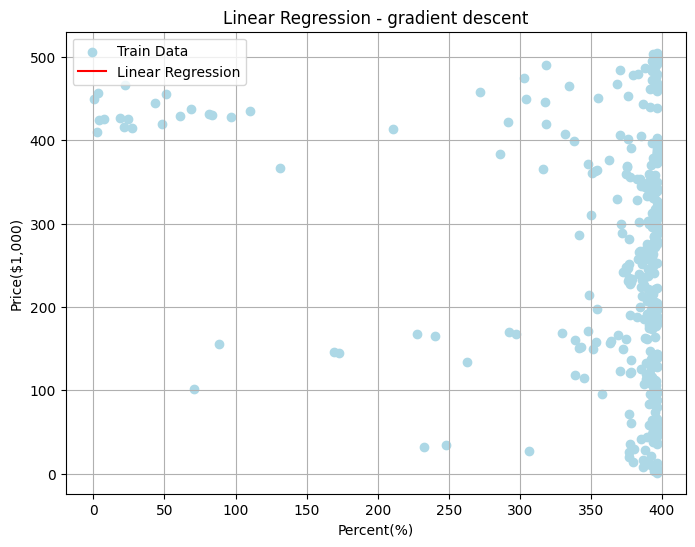

In [68]:
# 1. 선형 회귀 모델 구성
# 1) 경사하강법을 이용해서 모델을 학습하고, 모델을 시각화하라.

def gradient_descent(x, y, lr = 0.01, epochs = 10000):
  m = 0
  b = 0
  n = len(x)

  for _ in range(epochs):
    y_pred = m * x + b
    error = y_pred - y
    m_grad = (2/n) * np.dot(error, x)
    b_grad = (2/n) * np.sum(error)
    m -= lr * m_grad
    b -= lr * b_grad
  return m, b

x_train = X_train.flatten()
m, b = gradient_descent(x_train, y_train)

# 시각화하기

plt.figure(figsize = (8,6))
plt.scatter(x_train, y_train, color = 'lightblue', label = 'Train Data')
plt.plot(x_train, m * x_train + b, color = 'red', label = 'Linear Regression')
plt.xlabel("Percent(%)")
plt.ylabel("Price($1,000)")
plt.title("Linear Regression - gradient descent")
plt.legend()
plt.grid(True)
plt.show()

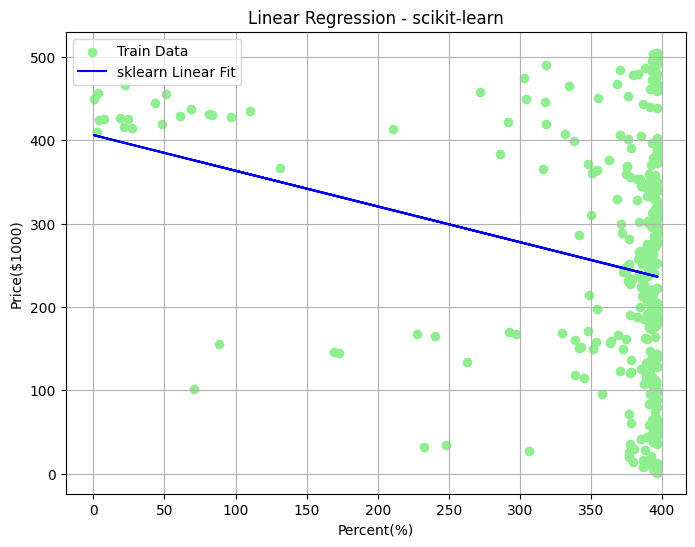

In [67]:
# 1-2 : scikit-learn을 이용해서 모델을 학습하고, 모델을 시각화하기

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_train = lin_model.predict(X_train)

# 시각화
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='lightgreen', label='Train Data')
plt.plot(X_train, y_pred_train, color='blue', label='sklearn Linear Fit')
plt.xlabel("Percent(%)")
plt.ylabel("Price($1000)")
plt.title("Linear Regression - scikit-learn")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-66-3c05af7b5df9>:12: RuntimeWarning: overflow encountered in matmul
  grad = (2/n) * X_poly.T @ error
<ipython-input-66-3c05af7b5df9>:13: RuntimeWarning: invalid value encountered in subtract
  theta -= lr * grad


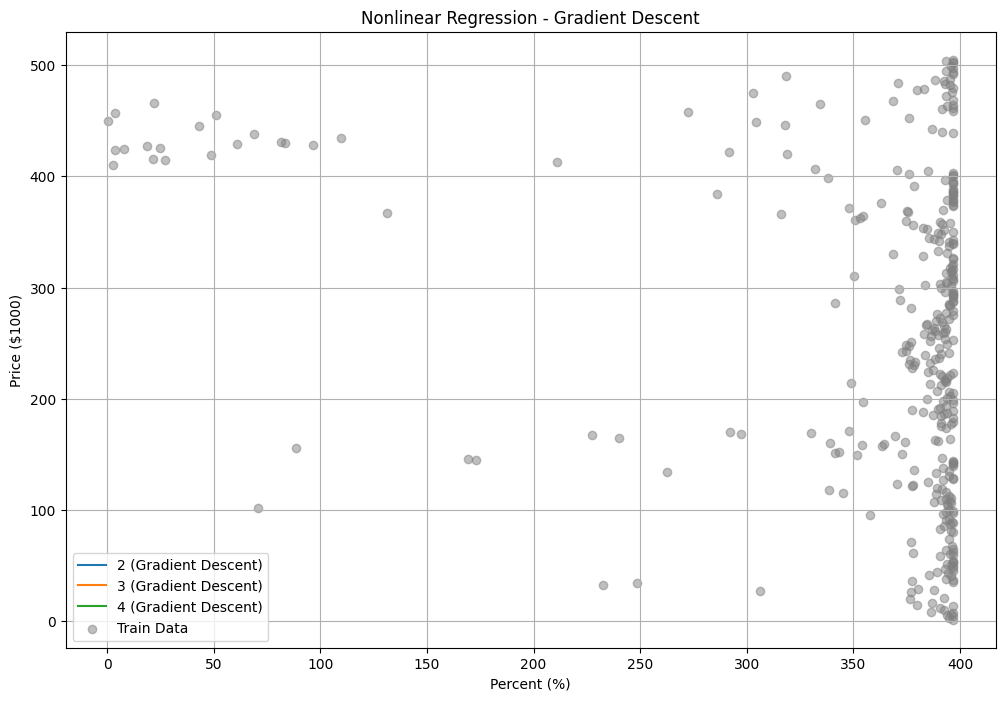

In [66]:
# 2. 비선형(2~4차) 회귀 모델 구성
# 2-1 경사하강법으로 모델을 학습하고, 모델을 시각화하기

def poly_gradient_descent(x, y, degree, lr=0.01, epochs=10000):
    X_poly = np.vander(x, N=degree+1, increasing=True)
    theta = np.zeros(X_poly.shape[1])
    n = len(y)

    for _ in range(epochs):
        y_pred = X_poly @ theta
        error = y_pred - y
        grad = (2/n) * X_poly.T @ error
        theta -= lr * grad
    return theta

x_train = X_train.flatten()

plt.figure(figsize=(12,8))
for degree in range(2, 5):
    theta = poly_gradient_descent(x_train, y_train, degree)
    x_fit = np.linspace(min(x_train), max(x_train), 200)
    X_fit_poly = np.vander(x_fit, N=degree+1, increasing=True)
    y_fit = X_fit_poly @ theta

    plt.plot(x_fit, y_fit, label=f'{degree} (Gradient Descent)')

plt.scatter(x_train, y_train, color='gray', alpha=0.5, label='Train Data')
plt.xlabel("Percent (%)")
plt.ylabel("Price ($1000)")
plt.title("Nonlinear Regression - Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

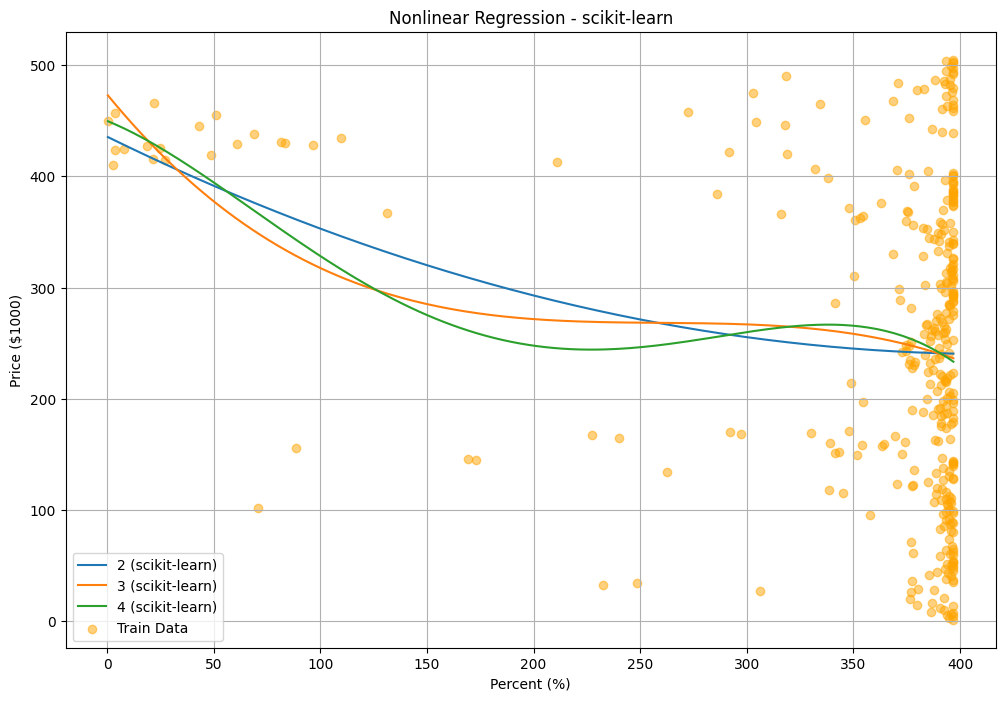

In [65]:
# 2-2 : scikit-learn을 이용해서 모델을 학습하고, 모델을 시각화하기

plt.figure(figsize=(12,8))
for degree in range(2, 5):
    poly = PolynomialFeatures(degree)
    X_poly_train = poly.fit_transform(X_train)
    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    x_fit = np.linspace(min(x_train), max(x_train), 200).reshape(-1, 1)
    x_fit_poly = poly.transform(x_fit)
    y_fit = model.predict(x_fit_poly)

    plt.plot(x_fit, y_fit, label=f'{degree} (scikit-learn)')

plt.scatter(X_train, y_train, color='orange', alpha=0.5, label='Train Data')
plt.xlabel("Percent (%)")
plt.ylabel("Price ($1000)")
plt.title("Nonlinear Regression - scikit-learn")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/multivariate_data.csv')
print(df)

        C1_X1     C1_X2     C2_X1     C2_X2     C3_X1     C3_X2     C4_X1  \
0    2.706225  9.407781  5.824904  7.525201  3.351950  3.334114  3.840876   
1    2.697701  7.247543  5.374379  7.453444  2.503363  4.641112  5.881083   
2    1.252542  7.242958  8.823484  8.679760  2.032260  5.951610  5.342140   
3    3.321254  9.939797  6.378003  8.536353  2.234694  5.162765  3.490318   
4    2.167483  7.780104  5.152108  7.719592  3.064460  3.326044  5.995217   
..        ...       ...       ...       ...       ...       ...       ...   
195  2.018151  6.420628  4.576973  8.339415  0.989093  6.880533  6.853132   
196  2.706027  8.743245  5.614309  7.398171  3.859967  2.197157  5.492366   
197  1.729778  7.578610  4.514036  7.528052  2.854985  3.730421  5.062393   
198  1.906434  6.569859  5.945178  7.104036  1.525352  5.574086  6.960799   
199  1.981190  6.106872  5.111637  9.147630  2.108853  6.252995  6.784043   

        C4_X2  
0    5.577376  
1    6.300002  
2    4.099992  
3    5.8245

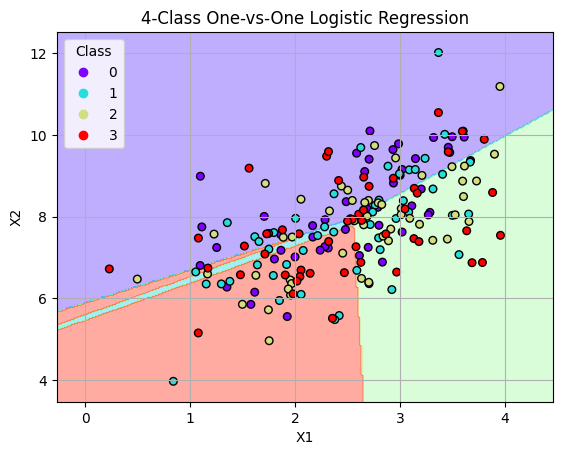

In [63]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/multivariate_data.csv')

# 클래스 라벨 부여하기
df['label'] = np.repeat(['Class1', 'Class2', 'Class3', 'Class4'], len(df) // 4)

# 입력(X), 타겟(y) 정의
X = df[['C1_X1', 'C1_X2']].values
y = LabelEncoder().fit_transform(df['label'].values)

# 로지스틱 회귀 (One-vs-One) 모델 학습
model = OneVsOneClassifier(LogisticRegression())
model.fit(X, y)

# 시각화 함수 정의
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.rainbow)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.rainbow, edgecolors='k')
    plt.legend(*scatter.legend_elements(), title="Class")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# 시각화 실행
plot_decision_boundary(model, X, y, "4-Class One-vs-One Logistic Regression")

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


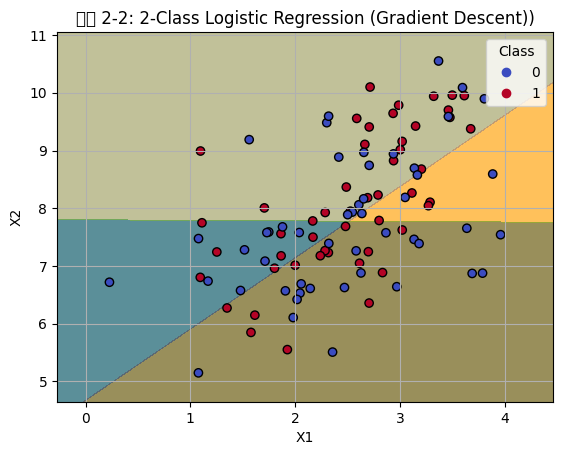

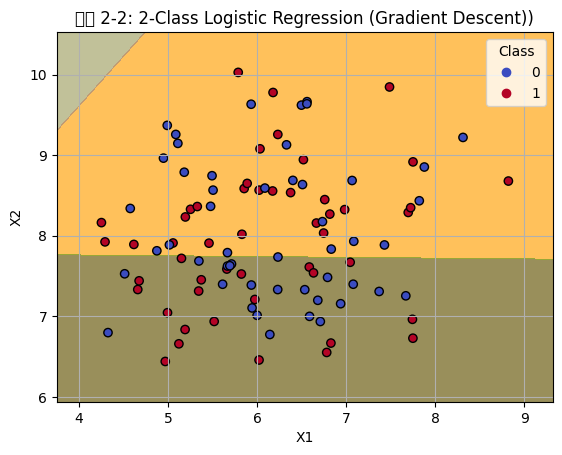

In [62]:
# Class1 = 1, Class4 = 0 으로 필터링 및 레이블링하기
df_bin = df[df['label'].isin(['Class1', 'Class4'])].copy()
df_bin['binary_label'] = df_bin['label'].apply(lambda x: 1 if x == 'Class1' else 0)

# 입력(X), 타겟(y)
X1_bin = df_bin[['C1_X1', 'C1_X2']].values
X2_bin = df_bin[['C2_X1', 'C2_X2']].values
y_bin = df_bin['binary_label'].values

def sigmoid(z): # 시그모이드 함수 정의
    return 1 / (1 + np.exp(-z))

def logistic_gradient(X, y, lr=0.01, epochs=10000):
    X = np.c_[np.ones(X.shape[0]), X]
    theta = np.zeros(X.shape[1])

    for _ in range(epochs):
        z = X @ theta
        h = sigmoid(z)
        gradient = X.T @ (h - y) / len(y)
        theta -= lr * gradient
    return theta

# 학습하기
theta1 = logistic_gradient(X1_bin, y_bin)
theta2 = logistic_gradient(X2_bin, y_bin)

def plot_logistic_boundary(X, y, theta, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    X_grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
    Z1 = sigmoid(X_grid @ theta1).reshape(xx.shape)
    Z2 = sigmoid(X_grid @ theta2).reshape(xx.shape)

    plt.contourf(xx, yy, Z1, levels=[0, 0.5, 1], alpha=0.4, colors=["red", "blue"])
    plt.contourf(xx, yy, Z2, levels=[0, 0.5, 1], alpha=0.4, colors=["yellow", "green"])
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.legend(*scatter.legend_elements(), title="Class")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# 시각화 실행하기
plot_logistic_boundary(X1_bin, y_bin, theta1, "문제 2-2: 2-Class Logistic Regression (Gradient Descent))")
plot_logistic_boundary(X2_bin, y_bin, theta2, "문제 2-2: 2-Class Logistic Regression (Gradient Descent))")